<h1 style="text-align:center;">Numerical Methods for <br>Stochastic Differential Equations<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<p style="text-align:center;">Appendix: Python Code</p>

In [1]:
import math
import numpy as np
import logging
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('TkAgg')
%matplotlib inline
logging.getLogger().setLevel(logging.ERROR)
random_seed = 14

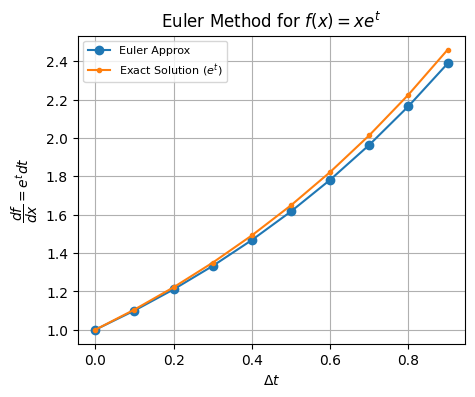

In [4]:
## Compare analytical solution to Euler approximation on ODE
# f(x)  = xe^t
# df/dx = e^tdt
def dfdx(t):
    return np.exp(t)

# Parameters
N = 10                # Number of increments
T = 1                 # Time horizon
dt = T/N              # Step size
t = np.arange(0,1,dt) # timesteps
y0 = 1

# Euler approximation
y = np.zeros(N)
y[0] = y0
for i in range(1, N):
    y[i] = y[i-1] + dfdx(t[i-1])*dt

# Exact Solution for comparison: df/dx = e^tdt
y_exp = np.exp(t)

plt.figure(figsize=(5, 4))
plt.plot(t, y, marker="o", label='Euler Approx')
plt.plot(t, y_exp, marker=".", label='Exact Solution ($e^t$)')
plt.title('Euler Method for $f(x)=xe^t$',size=12)
plt.xlabel('$\Delta t$')
plt.ylabel('$\dfrac{df}{dx}=e^tdt$')
plt.legend(prop={"size":8})
plt.grid(":")
plt.savefig("images/euler_method.png")
plt.show()

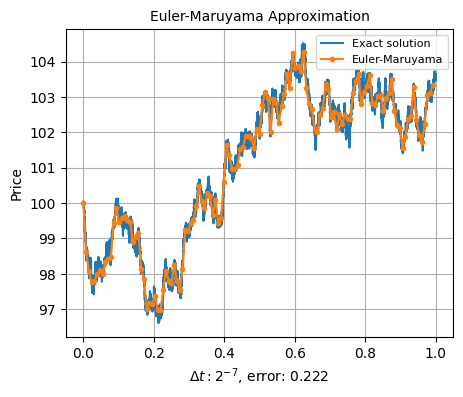

In [36]:
## Compare analytical solution to Euler approximation of SDE
np.random.seed(random_seed)
mu = 0.03      # Drift
sigma = 0.05   # Diffusion
x0 = 100       # Initial price
N = 2**15      # Brownian increments
T = 1          # Time horizon
dt = T/N       # Time step size
W = np.sqrt(dt)*np.random.normal(0, 1, size=N) # Brownian

# Exact solution using Brownian motion with dt
Wt = W.cumsum()
t = np.arange(0, T, dt)
Xt = np.zeros(len(t))
Xt[0] = x0
for i in range(1,len(t)):
    Xt[i] = x0 * np.exp((mu-0.5*sigma**2) * t[i-1] + sigma*Wt[i-1])
    
# Euler-Maruyama approximation
I = 2**7        # Euler increments
step = int(N/I) # Adjusted Brownian increments
Dt = step*dt    # Euler step size
t_e = np.arange(0, T, Dt)
Xe = np.zeros(I)
Xe[0] = x0
# Recalculate to adjusted Euler increments
Wt_e = np.array([np.sum(W[k*step : (k+1)*step]) for k in range(I)])
for i in range(1, len(t_e)):
    Xe[i] = Xe[i-1] * ((1 + mu*Dt + sigma * Wt_e[i-1]).cumprod())

# Calculate discrepancy
error = np.sqrt((Xt[-1] - Xe[-1])**2)

plt.figure(figsize=(5, 4))
#fig = plt.figure(figsize=(5,4))
#ax = fig.add_subplot()
plt.plot(t, Xt, label="Exact solution")
plt.plot(t_e, Xe, marker=".", label="Euler-Maruyama")
plt.xlabel("$\Delta t: 2^{-7}$"+", error: {:.3f}".format(error))
plt.ylabel("Price")
plt.legend()
plt.legend(prop={"size":8})
plt.title(r"Euler-Maruyama Approximation", size=10)
plt.grid(":")
plt.savefig("images/euler_maruyama_approximation.png", bbox_inches='tight')
plt.show()

In [27]:
def least_square_fit(X, Y):
    """ Utility function to fit the line y = mx + c """
    A = np.vstack([np.log(X), np.ones(len(X))]).T
    y = np.log(Y)
    slope_intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    resid = np.linalg.norm(A.dot(slope_intercept) - y)**2
    return slope_intercept, resid

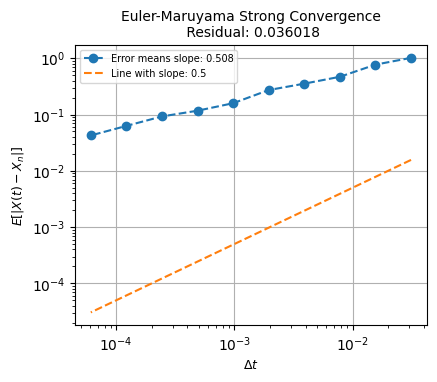

In [38]:
# Proof of Euler-Maruyama strong convergence order of 1/2
np.random.seed(random_seed)
mu = 2    # Drift
sigma = 1 # Diffusion
x0 = 1    # Starting price
N = 2**15 # Number of Brownian increments
T = 1     # Time horizon
dt = T/N  # Brownian step size
M = 100   # Number of MonteCarlo simulations
errors = np.zeros([M, 10]) # Matrix of errors

for m in range(M):  
    # Execute Monte-Carlo paths
    W = np.sqrt(dt) * np.random.normal(0,1,N)
    Wt = W.cumsum()
    for i in range(5,15):
        # Analytical solution 
        t = np.arange(0,T,dt)
        Xt = np.zeros(N)
        Xt[0] = x0
        for j in range(1, len(t)):
            Xt[j] = x0 * np.exp((mu-0.5*sigma**2)*t[j-1] + sigma*Wt[j-1])
            
        # Euler Approximation
        I = 2**i          # Euler Increments, <= Brownian increments to approximate
        step = round(N/I) # step size adjustment factor
        Dt = step*dt      # Euler adjusted time step
        te = np.arange(0, T, Dt)
        Wte = np.array([np.sum(W[k*step : (k+1)*step])for k in range(I)])
        Xe = np.zeros(I)
        Xe[0]=x0
        for l in range(1, len(te)):
            Xe[l] = Xe[l-1] * (1 + mu*Dt + sigma*Wte[l-1])
            
        # Errors
        errors[m, i-5] = np.abs(Xt[-1] - Xe[-1])

# Vector of Euler time step sizes used as X values and error means as Y values
Dts = np.array([2**x for x in range(-5, -15, -1)])
err_means = errors.mean(axis=0)
lst_sqr_fit, resid = least_square_fit(Dts, err_means)

rho, intercept = lst_sqr_fit
#assert math.isclose(m, 0.5, abs_tol=0.01)

fig =  plt.figure(figsize=(10,8))
ax = fig.add_subplot(221)
ax.loglog(Dts, err_means, marker="o", linestyle="dashed",
          label= "Error means slope: {:.3f}".format(rho))
ax.loglog(Dts, 0.5*Dts, linestyle="dashed", 
          label="Line with slope: 0.5")
ax.set_xlabel("$\Delta t$", size=9)
ax.set_ylabel("$E[|X(t)-X_n|]$", size=9)
ax.set_title("Euler-Maruyama Strong Convergence\n"
             + " Residual: {:.6f}".format(resid), size=10)
ax.legend(prop={"size":7})
ax.grid(":")
plt.savefig("images/euler_maruyama_strong_convergence.png", bbox_inches='tight')
plt.show()

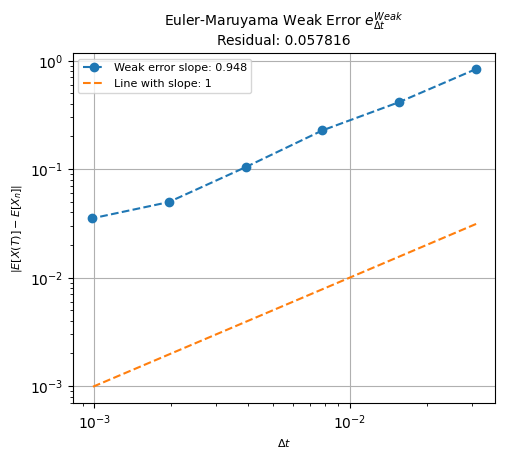

In [37]:
# Proof of Euler-Maruyama weak convergence order of 1
np.random.seed(random_seed)
mu = 2            # Drift
sigma = 1         # Diffusion
x0 = 1            # Initial value
N = 2**15         # Number of discrete Brownian increments
T = 1             # Time horizon
dt = T/N          # Step size
M = 10**6         # Monte-Carlo simulation paths
Xe = np.zeros(6)  # Price data array

for i in range(5, 11):
    I = 2**i  # Number of Euler increments
    step = round(N/I)
    Dt = step*dt
    temp = np.zeros((M, I))
    for m in range(M):
        Wt = np.sqrt(Dt) * np.random.normal(0, 1, I)
        temp[m, 0] = x0
        for t in range(1, I):
            temp[m, t] = temp[m, t-1] * (1 + mu*Dt + sigma*Wt[t-1]) 
    Xe[i-5] = np.mean(temp[:,-1])
    
weak_errors = abs(Xe - x0 * np.exp(mu*T))
weak_errors = weak_errors.T

Dts = np.array([2**x for x in range(-5, -11, -1)])
([slope, intercept], residual) = least_square_fit(Dts, weak_errors)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(221)
ax.loglog(Dts, abs(weak_errors), marker="o",
          linestyle="dashed", label="Weak error slope: {:.3f}".format(slope))
ax.loglog(Dts, Dts, linestyle="dashed", label="Line with slope: 1")
ax.set_xlabel("$\Delta t$", size=8)
ax.set_ylabel("$|E[X(T)]-E[X_n]|$", size=8)   
ax.set_title("Euler-Maruyama Weak Error $e_{\Delta t}^{Weak}$ \n" 
            + "Residual: {:.6f}".format(residual), size=10)
ax.legend(prop={"size":8})
ax.grid(":")
plt.savefig("images/euler_maruyama_weak_convergence.png", bbox_inches='tight')
plt.show()